# Environment and Imports

In [4]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [5]:
from pathlib import Path

PROJECT_DIR = Path.cwd()

SWINIR_DIR = PROJECT_DIR / "SwinIR"
CACHE_DIR = PROJECT_DIR / "dataset_cache"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
OUTPUT_DIR = PROJECT_DIR / "outputs"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT:", PROJECT_DIR)
print("CACHE:", CACHE_DIR)

PROJECT: C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART
CACHE: C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\dataset_cache


In [6]:
import subprocess

if not SWINIR_DIR.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/JingyunLiang/SwinIR.git",
            str(SWINIR_DIR)
        ],
        check=True
    )
else:
    print("SwinIR already exists.")

SwinIR already exists.


In [7]:
import os

os.chdir(SWINIR_DIR)

print(os.getcwd())

C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR


In [8]:
import os

print("Current directory:")
print(os.getcwd())

print("\nSwinIR exists:")
print(os.path.exists("main_test_swinir.py"))

Current directory:
C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR

SwinIR exists:
True


In [9]:
import sys

!"{sys.executable}" -m pip install timm einops opencv-python rasterio matplotlib numpy tqdm scikit-image tacoreader==0.4.5

# Download/Load Pretrained SwinIR x4 Model

In [10]:
from pathlib import Path

MODEL_DIR = SWINIR_DIR / "model_zoo" / "swinir"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(MODEL_DIR)

C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR\model_zoo\swinir


In [11]:
import urllib.request

MODEL_URL = (
    "https://github.com/JingyunLiang/SwinIR/releases/download/v0.0/"
    "001_classicalSR_DIV2K_s48w8_SwinIR-M_x4.pth"
)

MODEL_PATH = (
    MODEL_DIR /
    "001_classicalSR_DIV2K_s48w8_SwinIR-M_x4.pth"
)

if not MODEL_PATH.exists():

    print("Downloading model...")

    urllib.request.urlretrieve(
        MODEL_URL,
        MODEL_PATH
    )

else:

    print("Pretrained model already exists.")

print(MODEL_PATH)

Pretrained model already exists.
C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR\model_zoo\swinir\001_classicalSR_DIV2K_s48w8_SwinIR-M_x4.pth


In [12]:
print("Model exists:", MODEL_PATH.exists())
print("Model path:", MODEL_PATH)

Model exists: True
Model path: C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR\model_zoo\swinir\001_classicalSR_DIV2K_s48w8_SwinIR-M_x4.pth


STEP 4 — Install the satellite dataset dependencies

SEN2NAIPv2 uses the TACO format and its dataset documentation recommends tacoreader and rasterio.

In [13]:
import tacoreader
import rasterio as rio
import matplotlib.pyplot as plt
import numpy as np

In [14]:
import sys

!"{sys.executable}" -m pip uninstall -y tacoreader
!"{sys.executable}" -m pip install tacoreader==0.4.5

Found existing installation: tacoreader 0.4.5
Uninstalling tacoreader-0.4.5:
  Successfully uninstalled tacoreader-0.4.5
  Using cached tacoreader-0.4.5-py3-none-any.whl.metadata (3.4 kB)
Using cached tacoreader-0.4.5-py3-none-any.whl (17 kB)


In [15]:
print(tacoreader.__version__)

0.4.5


# Load SEN2NAIP dataset

In [16]:
dataset = tacoreader.load(
    "tacofoundation:sen2naipv2-unet"
)

print(dataset)

      internal:mode                                   internal:subfile  \
0            online  /vsisubfile/200_1195059,/vsicurl/https://huggi...   
1            online  /vsisubfile/1195259_1003267,/vsicurl/https://h...   
2            online  /vsisubfile/2198526_1133098,/vsicurl/https://h...   
3            online  /vsisubfile/3331624_1141332,/vsicurl/https://h...   
4            online  /vsisubfile/4472956_1016129,/vsicurl/https://h...   
...             ...                                                ...   
61277        online  /vsisubfile/19994241243_1018712,/vsicurl/https...   
61278        online  /vsisubfile/19995259955_1018679,/vsicurl/https...   
61279        online  /vsisubfile/19996278634_1063683,/vsicurl/https...   
61280        online  /vsisubfile/19997342317_1235765,/vsicurl/https...   
61281        online  /vsisubfile/19998578082_1277277,/vsicurl/https...   

                                           tortilla:id tortilla:file_format  \
0      NA5120_E1940N0771__m_4107

In [17]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [18]:
sample_idx = 4000

sample = dataset.read(sample_idx)

lr_path = sample.read(0)
hr_path = sample.read(1)

print("LR:", lr_path)
print("HR:", hr_path)

LR: /vsisubfile/4623289435_75411,/vsicurl/https://huggingface.co/datasets/tacofoundation/SEN2NAIPv2/resolve/main/sen2naipv2-unet.0003.part.taco
HR: /vsisubfile/4623364846_1075486,/vsicurl/https://huggingface.co/datasets/tacofoundation/SEN2NAIPv2/resolve/main/sen2naipv2-unet.0003.part.taco


In [19]:
sample = dataset.read(sample_idx)

lr_path = sample.read(0)
hr_path = sample.read(1)

In [20]:
with rio.open(lr_path) as src:

    lr_data = src.read(
        window=rio.windows.Window(
            0,
            0,
            64,
            64
        )
    )

with rio.open(hr_path) as src:

    hr_data = src.read(
        window=rio.windows.Window(
            0,
            0,
            256,
            256
        )
    )

In [21]:
print("LR shape:", lr_data.shape)
print("HR shape:", hr_data.shape)

LR shape: (4, 64, 64)
HR shape: (4, 256, 256)


In [22]:
def to_rgb(image):

    # Dataset order:
    # R = 0
    # G = 1
    # B = 2

    rgb = image[:3].transpose(1, 2, 0)

    rgb = rgb / 3000.0

    return np.clip(rgb, 0, 1)

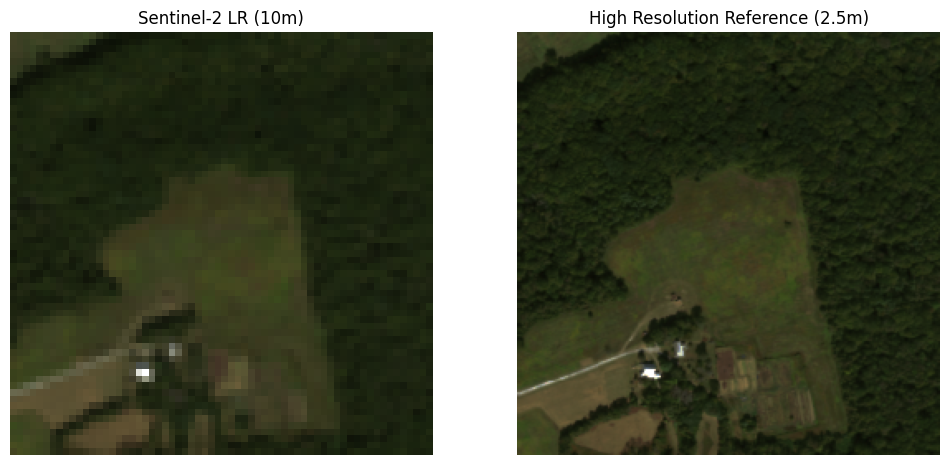

In [23]:
lr_rgb = to_rgb(lr_data)
hr_rgb = to_rgb(hr_data)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)

plt.imshow(lr_rgb)
plt.title("Sentinel-2 LR (10m)")
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(hr_rgb)
plt.title("High Resolution Reference (2.5m)")
plt.axis("off")

plt.show()

In [24]:
import torch

from torch.utils.data import Dataset

In [25]:
class SatelliteSRDataset(Dataset):

    def __init__(
        self,
        taco_dataset,
        indices
    ):

        self.dataset = taco_dataset

        self.indices = indices


    def __len__(self):

        return len(self.indices)


    def __getitem__(self, idx):

        sample_idx = self.indices[idx]

        sample = self.dataset.read(sample_idx)

        lr_path = sample.read(0)
        hr_path = sample.read(1)


        # -----------------------
        # READ LOW RESOLUTION
        # -----------------------

        with rio.open(lr_path) as src:

            lr = src.read(
                window=rio.windows.Window(
                    0,
                    0,
                    64,
                    64
                )
            )


        # -----------------------
        # READ HIGH RESOLUTION
        # -----------------------

        with rio.open(hr_path) as src:

            hr = src.read(
                window=rio.windows.Window(
                    0,
                    0,
                    256,
                    256
                )
            )


        # -----------------------
        # SELECT RGB
        # -----------------------

        lr = lr[:3]

        hr = hr[:3]


        # -----------------------
        # CONVERT TO TENSOR
        # -----------------------

        lr = torch.tensor(
            lr,
            dtype=torch.float32
        )

        hr = torch.tensor(
            hr,
            dtype=torch.float32
        )


        # -----------------------
        # NORMALIZATION
        # -----------------------

        lr = lr / 3000.0

        hr = hr / 3000.0


        # -----------------------
        # CLAMP
        # -----------------------

        lr = torch.clamp(
            lr,
            0,
            1
        )

        hr = torch.clamp(
            hr,
            0,
            1
        )


        return lr, hr

# PreProcessing

In [26]:
train_indices = list(range(0, 500))

val_indices = list(range(500, 600))

test_indices = list(range(600, 700))

In [27]:
train_dataset = SatelliteSRDataset(
    dataset,
    train_indices
)

val_dataset = SatelliteSRDataset(
    dataset,
    val_indices
)

test_dataset = SatelliteSRDataset(
    dataset,
    test_indices
)

# Create Local Dataset Cache

In [28]:
import os
from pathlib import Path

# PROJECT_DIR should already have been created earlier.
# If not, this sets it to the folder containing/running the notebook.
PROJECT_DIR = Path.cwd()

# Local Windows cache folder
CACHE_DIR = PROJECT_DIR / "dataset_cache"

# Training folders
TRAIN_LR_DIR = CACHE_DIR / "train" / "lr"
TRAIN_HR_DIR = CACHE_DIR / "train" / "hr"

# Validation folders
VAL_LR_DIR = CACHE_DIR / "val" / "lr"
VAL_HR_DIR = CACHE_DIR / "val" / "hr"

# Test folders
TEST_LR_DIR = CACHE_DIR / "test" / "lr"
TEST_HR_DIR = CACHE_DIR / "test" / "hr"


# Create all folders
for directory in [
    TRAIN_LR_DIR,
    TRAIN_HR_DIR,
    VAL_LR_DIR,
    VAL_HR_DIR,
    TEST_LR_DIR,
    TEST_HR_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)


print("Cache folders created!")
print("Cache location:", CACHE_DIR)

Cache folders created!
Cache location: C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR\dataset_cache


In [29]:
def count_cached(directory):
    return len(list(Path(directory).glob("*.pt")))


print("Train LR cached:", count_cached(TRAIN_LR_DIR))
print("Train HR cached:", count_cached(TRAIN_HR_DIR))

print("Val LR cached:", count_cached(VAL_LR_DIR))
print("Val HR cached:", count_cached(VAL_HR_DIR))

print("Test LR cached:", count_cached(TEST_LR_DIR))
print("Test HR cached:", count_cached(TEST_HR_DIR))

Train LR cached: 500
Train HR cached: 500
Val LR cached: 100
Val HR cached: 100
Test LR cached: 100
Test HR cached: 100


In [30]:
import torch
from tqdm import tqdm


def cache_dataset_local(dataset, lr_dir, hr_dir):

    lr_dir = Path(lr_dir)
    hr_dir = Path(hr_dir)

    for i in tqdm(range(len(dataset))):

        lr_path = lr_dir / f"{i:06d}.pt"
        hr_path = hr_dir / f"{i:06d}.pt"

        # Skip if both files already exist
        if lr_path.exists() and hr_path.exists():
            continue

        lr, hr = dataset[i]

        # Save only missing files
        if not lr_path.exists():
            torch.save(lr.cpu(), lr_path)

        if not hr_path.exists():
            torch.save(hr.cpu(), hr_path)

In [31]:
cache_dataset_local(
    train_dataset,
    TRAIN_LR_DIR,
    TRAIN_HR_DIR
)

100%|██████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 2396.87it/s]


In [32]:
print("Train LR:", count_cached(TRAIN_LR_DIR))
print("Train HR:", count_cached(TRAIN_HR_DIR))

Train LR: 500
Train HR: 500


In [33]:
cache_dataset_local(
    val_dataset,
    VAL_LR_DIR,
    VAL_HR_DIR
)

100%|██████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 2127.19it/s]


In [34]:
print("Val LR:", count_cached(VAL_LR_DIR))
print("Val HR:", count_cached(VAL_HR_DIR))

Val LR: 100
Val HR: 100


In [35]:
cache_dataset_local(
    test_dataset,
    TEST_LR_DIR,
    TEST_HR_DIR
)

100%|██████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 1449.64it/s]


In [36]:
from torch.utils.data import Dataset
from pathlib import Path
import torch


class LocalSatelliteSRDataset(Dataset):

    def __init__(self, lr_dir, hr_dir):

        self.lr_dir = Path(lr_dir)
        self.hr_dir = Path(hr_dir)

        self.lr_files = sorted(
            self.lr_dir.glob("*.pt")
        )

        self.hr_files = sorted(
            self.hr_dir.glob("*.pt")
        )

        assert len(self.lr_files) == len(self.hr_files), \
            "LR and HR file counts do not match!"

    def __len__(self):

        return len(self.lr_files)

    def __getitem__(self, index):

        lr = torch.load(
            self.lr_files[index],
            map_location="cpu"
        )

        hr = torch.load(
            self.hr_files[index],
            map_location="cpu"
        )

        return lr.float(), hr.float()

# Create Local Dataset Caches

In [37]:
local_train_dataset = LocalSatelliteSRDataset(
    TRAIN_LR_DIR,
    TRAIN_HR_DIR
)

local_val_dataset = LocalSatelliteSRDataset(
    VAL_LR_DIR,
    VAL_HR_DIR
)

local_test_dataset = LocalSatelliteSRDataset(
    TEST_LR_DIR,
    TEST_HR_DIR
)


print("Train:", len(local_train_dataset))
print("Validation:", len(local_val_dataset))
print("Test:", len(local_test_dataset))

Train: 500
Validation: 100
Test: 100


In [38]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4

train_loader = DataLoader(
    local_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,      # IMPORTANT for Windows/Jupyter
    pin_memory=True
)

val_loader = DataLoader(
    local_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    local_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [39]:
lr_batch, hr_batch = next(iter(train_loader))

print("LR batch shape:", lr_batch.shape)
print("HR batch shape:", hr_batch.shape)

LR batch shape: torch.Size([4, 3, 64, 64])
HR batch shape: torch.Size([4, 3, 256, 256])


In [40]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [41]:
import os

os.chdir(SWINIR_DIR)

print("Current directory:", os.getcwd())

Current directory: C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR


In [42]:
from models.network_swinir import SwinIR

C:\Users\Anuj Pethe\AppData\Local\Programs\Python\Python310\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


# Initializing Model Fine Tuning

In [43]:
model = SwinIR(
    upscale=4,
    in_chans=3,
    img_size=64,
    window_size=8,
    img_range=1.0,
    depths=[6, 6, 6, 6, 6, 6],
    embed_dim=180,
    num_heads=[6, 6, 6, 6, 6, 6],
    mlp_ratio=2,
    upsampler="pixelshuffle",
    resi_connection="1conv"
)

C:\Users\Anuj Pethe\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4217.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [44]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu"
)

print(checkpoint.keys())

dict_keys(['params'])


In [45]:
state_dict = checkpoint["params"].copy()

# Remove dynamically generated attention masks
for key in list(state_dict.keys()):
    if "attn_mask" in key:
        del state_dict[key]

# Load remaining pretrained weights
missing_keys, unexpected_keys = model.load_state_dict(
    state_dict,
    strict=False
)

print("Pretrained SwinIR loaded successfully!")

print("\nMissing keys:")
print(missing_keys)

print("\nUnexpected keys:")
print(unexpected_keys)

Pretrained SwinIR loaded successfully!

Missing keys:
['layers.0.residual_group.blocks.1.attn_mask', 'layers.0.residual_group.blocks.3.attn_mask', 'layers.0.residual_group.blocks.5.attn_mask', 'layers.1.residual_group.blocks.1.attn_mask', 'layers.1.residual_group.blocks.3.attn_mask', 'layers.1.residual_group.blocks.5.attn_mask', 'layers.2.residual_group.blocks.1.attn_mask', 'layers.2.residual_group.blocks.3.attn_mask', 'layers.2.residual_group.blocks.5.attn_mask', 'layers.3.residual_group.blocks.1.attn_mask', 'layers.3.residual_group.blocks.3.attn_mask', 'layers.3.residual_group.blocks.5.attn_mask', 'layers.4.residual_group.blocks.1.attn_mask', 'layers.4.residual_group.blocks.3.attn_mask', 'layers.4.residual_group.blocks.5.attn_mask', 'layers.5.residual_group.blocks.1.attn_mask', 'layers.5.residual_group.blocks.3.attn_mask', 'layers.5.residual_group.blocks.5.attn_mask']

Unexpected keys:
[]


In [46]:
model = model.to(device)

print("Model moved to:", device)

Model moved to: cuda


In [47]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using:", device)

model = model.to(device)

Using: cuda


In [48]:
print(next(model.parameters()).device)

cuda:0


In [49]:
import torch.nn as nn

criterion = nn.L1Loss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

print("Loss and optimizer ready!")

Loss and optimizer ready!


In [50]:
from pathlib import Path

CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = CHECKPOINT_DIR / "best_swinir_sen2naip.pth"
LATEST_MODEL_PATH = CHECKPOINT_DIR / "latest_swinir_sen2naip.pth"

print("Best model path:", BEST_MODEL_PATH)
print("Latest model path:", LATEST_MODEL_PATH)

Best model path: C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR\checkpoints\best_swinir_sen2naip.pth
Latest model path: C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR\checkpoints\latest_swinir_sen2naip.pth


In [51]:
model.train()

lr_batch, hr_batch = next(iter(train_loader))

lr_batch = lr_batch.to(device)
hr_batch = hr_batch.to(device)

print("LR input:", lr_batch.shape)
print("HR target:", hr_batch.shape)

with torch.cuda.amp.autocast():
    output = model(lr_batch)

print("Model output:", output.shape)

LR input: torch.Size([4, 3, 64, 64])
HR target: torch.Size([4, 3, 256, 256])


C:\Users\Anuj Pethe\AppData\Local\Temp\ipykernel_21924\1926015031.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Model output: torch.Size([4, 3, 256, 256])


In [52]:
model.train()

lr_batch, hr_batch = next(iter(train_loader))

lr_batch = lr_batch.to(device, non_blocking=True)
hr_batch = hr_batch.to(device, non_blocking=True)

optimizer.zero_grad()

with torch.amp.autocast("cuda"):
    output = model(lr_batch)
    loss = criterion(output, hr_batch)

print("Loss:", loss.item())

loss.backward()

optimizer.step()

print("One training step completed successfully!")

Loss: nan
One training step completed successfully!


## DEBUGGING STAGE


In [53]:
lr_batch, hr_batch = next(iter(train_loader))

print("LR has NaN:", torch.isnan(lr_batch).any().item())
print("LR has Inf:", torch.isinf(lr_batch).any().item())
print("LR min:", lr_batch.min().item())
print("LR max:", lr_batch.max().item())

print()

print("HR has NaN:", torch.isnan(hr_batch).any().item())
print("HR has Inf:", torch.isinf(hr_batch).any().item())
print("HR min:", hr_batch.min().item())
print("HR max:", hr_batch.max().item())

LR has NaN: False
LR has Inf: False
LR min: 0.054666668176651
LR max: 1.0

HR has NaN: False
HR has Inf: False
HR min: 0.041333332657814026
HR max: 1.0


In [54]:
checkpoint = torch.load(MODEL_PATH, map_location="cpu")
state_dict = checkpoint["params"].copy()

for key in list(state_dict.keys()):
    if "attn_mask" in key:
        del state_dict[key]

model.load_state_dict(state_dict, strict=False)
model = model.to(device)

print("Fresh pretrained model reloaded!")

Fresh pretrained model reloaded!


In [55]:
model.eval()

lr_batch, hr_batch = next(iter(train_loader))

lr_batch = lr_batch.to(device)
hr_batch = hr_batch.to(device)

with torch.no_grad():
    output = model(lr_batch)

print("Output has NaN:", torch.isnan(output).any().item())
print("Output has Inf:", torch.isinf(output).any().item())

print("Output min:", output.min().item())
print("Output max:", output.max().item())

loss = criterion(output, hr_batch)

print("Loss:", loss.item())
print("Loss is NaN:", torch.isnan(loss).item())

Output has NaN: False
Output has Inf: False
Output min: 0.02802678942680359
Output max: 1.0531446933746338
Loss: 0.027936603873968124
Loss is NaN: False


In [56]:
model.train()

lr_batch, hr_batch = next(iter(train_loader))

lr_batch = lr_batch.to(device, non_blocking=True)
hr_batch = hr_batch.to(device, non_blocking=True)

optimizer.zero_grad()

# Normal FP32 forward pass — NO AMP
output = model(lr_batch)

loss = criterion(output, hr_batch)

print("Loss before backward:", loss.item())

loss.backward()

optimizer.step()

print("Training step completed!")

# Check model parameters for NaN
has_nan = any(
    torch.isnan(param).any().item()
    for param in model.parameters()
)

print("Model has NaN parameters:", has_nan)

Loss before backward: 0.018974853679537773
Training step completed!
Model has NaN parameters: True


In [57]:
checkpoint = torch.load(MODEL_PATH, map_location="cpu")
state_dict = checkpoint["params"].copy()

for key in list(state_dict.keys()):
    if "attn_mask" in key:
        del state_dict[key]

model.load_state_dict(state_dict, strict=False)
model = model.to(device)

print("Fresh pretrained model loaded!")

Fresh pretrained model loaded!


In [58]:
model.train()

lr_batch, hr_batch = next(iter(train_loader))

lr_batch = lr_batch.to(device)
hr_batch = hr_batch.to(device)

optimizer.zero_grad()

output = model(lr_batch)
loss = criterion(output, hr_batch)

print("Loss:", loss.item())

loss.backward()

has_nan_grad = False
has_inf_grad = False

for name, param in model.named_parameters():

    if param.grad is not None:

        if torch.isnan(param.grad).any():
            print("NaN gradient found in:", name)
            has_nan_grad = True
            break

        if torch.isinf(param.grad).any():
            print("Inf gradient found in:", name)
            has_inf_grad = True
            break


print("Has NaN gradients:", has_nan_grad)
print("Has Inf gradients:", has_inf_grad)

Loss: 0.022127099335193634
Has NaN gradients: False
Has Inf gradients: False


In [59]:
# Reload clean pretrained weights
checkpoint = torch.load(MODEL_PATH, map_location="cpu")
state_dict = checkpoint["params"].copy()

for key in list(state_dict.keys()):
    if "attn_mask" in key:
        del state_dict[key]

model.load_state_dict(state_dict, strict=False)
model = model.to(device)

# IMPORTANT: create a completely fresh optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

print("Clean model and fresh optimizer ready!")

Clean model and fresh optimizer ready!


In [60]:
model.train()

lr_batch, hr_batch = next(iter(train_loader))

lr_batch = lr_batch.to(device)
hr_batch = hr_batch.to(device)

optimizer.zero_grad()

# Forward pass
output = model(lr_batch)

# Loss
loss = criterion(output, hr_batch)

print("Loss before update:", loss.item())

# Backpropagation
loss.backward()

# Gradient clipping
grad_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=1.0
)

print("Gradient norm:", grad_norm.item())

# Update
optimizer.step()

# Check parameters
has_nan = any(
    torch.isnan(param).any().item()
    for param in model.parameters()
)

has_inf = any(
    torch.isinf(param).any().item()
    for param in model.parameters()
)

print("Model has NaN:", has_nan)
print("Model has Inf:", has_inf)

Loss before update: 0.01769900694489479
Gradient norm: 0.11043894290924072
Model has NaN: False
Model has Inf: False


In [61]:
checkpoint = torch.load(MODEL_PATH, map_location="cpu")

state_dict = checkpoint["params"].copy()

for key in list(state_dict.keys()):
    if "attn_mask" in key:
        del state_dict[key]

model.load_state_dict(state_dict, strict=False)

model = model.to(device)

print("Fresh pretrained model restored!")

Fresh pretrained model restored!


In [62]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

criterion = nn.L1Loss()

print("Fresh optimizer ready!")

Fresh optimizer ready!


# Resuming Training Model

In [63]:
import torch

checkpoint = torch.load(
    LATEST_MODEL_PATH,
    map_location=device
)

print("Checkpoint epoch:", checkpoint["epoch"])
print("Checkpoint train loss:", checkpoint["train_loss"])
print("Checkpoint validation loss:", checkpoint["val_loss"])

Checkpoint epoch: 5
Checkpoint train loss: 0.016510978884994983
Checkpoint validation loss: 0.01706277685239911


In [64]:
checkpoint = torch.load(
    LATEST_MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

start_epoch = checkpoint["epoch"]
best_val_loss = checkpoint["val_loss"]

print("Resuming from epoch:", start_epoch)
print("Next epoch will be:", start_epoch + 1)

Resuming from epoch: 5
Next epoch will be: 6


In [65]:
from tqdm import tqdm
import torch

best_val_loss = float("inf")
EPOCHS = 5

for epoch in range(start_epoch, EPOCHS):

    # =========================
    # TRAINING
    # =========================

    model.train()

    train_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS} Training"
    )

    for lr_batch, hr_batch in train_bar:

        lr_batch = lr_batch.to(
            device,
            non_blocking=True
        )

        hr_batch = hr_batch.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        # Forward pass
        output = model(lr_batch)

        # Calculate loss
        loss = criterion(
            output,
            hr_batch
        )

        # Safety check
        if torch.isnan(loss) or torch.isinf(loss):
            print("\nInvalid loss detected. Skipping batch.")
            continue

        # Backpropagation
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss += loss.item()

        train_bar.set_postfix(
            loss=f"{loss.item():.5f}"
        )


    avg_train_loss = (
        train_loss /
        len(train_loader)
    )


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        val_bar = tqdm(
            val_loader,
            desc=f"Epoch {epoch + 1}/{EPOCHS} Validation"
        )

        for lr_batch, hr_batch in val_bar:

            lr_batch = lr_batch.to(
                device,
                non_blocking=True
            )

            hr_batch = hr_batch.to(
                device,
                non_blocking=True
            )

            output = model(lr_batch)

            loss = criterion(
                output,
                hr_batch
            )

            if torch.isnan(loss) or torch.isinf(loss):
                print(
                    "\nInvalid validation loss detected."
                )
                continue

            val_loss += loss.item()


    avg_val_loss = (
        val_loss /
        len(val_loader)
    )


    # =========================
    # SAVE LATEST CHECKPOINT
    # =========================

    torch.save(
        {
            "epoch": epoch + 1,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "train_loss":
                avg_train_loss,

            "val_loss":
                avg_val_loss
        },

        LATEST_MODEL_PATH
    )


    # =========================
    # SAVE BEST CHECKPOINT
    # =========================

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            {
                "epoch": epoch + 1,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "train_loss":
                    avg_train_loss,

                "val_loss":
                    avg_val_loss
            },

            BEST_MODEL_PATH
        )

        print(
            f"\n⭐ New best model saved!"
        )


    # =========================
    # EPOCH RESULTS
    # =========================

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Train Loss: "
        f"{avg_train_loss:.6f}"
    )

    print(
        f"Validation Loss: "
        f"{avg_val_loss:.6f}"
    )

    print(
        f"Best Validation Loss: "
        f"{best_val_loss:.6f}"
    )

# Save Best Checkpoint after training Epochs

In [66]:
from pathlib import Path
import torch

print("Best model exists:", BEST_MODEL_PATH.exists())
print("Latest model exists:", LATEST_MODEL_PATH.exists())

if BEST_MODEL_PATH.exists():
    checkpoint = torch.load(BEST_MODEL_PATH, map_location="cpu")

    print("\nBEST CHECKPOINT INFO")
    print("Saved epoch:", checkpoint["epoch"])
    print("Train loss:", checkpoint["train_loss"])
    print("Validation loss:", checkpoint["val_loss"])

if LATEST_MODEL_PATH.exists():
    checkpoint = torch.load(LATEST_MODEL_PATH, map_location="cpu")

    print("\nLATEST CHECKPOINT INFO")
    print("Saved epoch:", checkpoint["epoch"])
    print("Train loss:", checkpoint["train_loss"])
    print("Validation loss:", checkpoint["val_loss"])

Best model exists: True
Latest model exists: True

BEST CHECKPOINT INFO
Saved epoch: 5
Train loss: 0.016510978884994983
Validation loss: 0.01706277685239911

LATEST CHECKPOINT INFO
Saved epoch: 5
Train loss: 0.016510978884994983
Validation loss: 0.01706277685239911


In [67]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Best checkpoint loaded!")
print("Epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])

Best checkpoint loaded!
Epoch: 5
Validation loss: 0.01706277685239911


In [68]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

print("Evaluation libraries ready!")

Evaluation libraries ready!


In [70]:
# ============================================================
# Additional Remote Sensing Metrics: SAM and ERGAS
# ============================================================

def calculate_sam(sr, hr, eps=1e-8):
    """
    Spectral Angle Mapper (SAM)
    Lower is better.
    """

    # [B, C, H, W] -> [B, H, W, C]
    sr = sr.permute(0, 2, 3, 1)
    hr = hr.permute(0, 2, 3, 1)

    # Flatten pixels
    sr = sr.reshape(-1, sr.shape[-1])
    hr = hr.reshape(-1, hr.shape[-1])

    # Dot product
    dot_product = torch.sum(sr * hr, dim=1)

    # Vector magnitudes
    sr_norm = torch.linalg.norm(sr, dim=1)
    hr_norm = torch.linalg.norm(hr, dim=1)

    # Cosine similarity
    cosine = dot_product / (sr_norm * hr_norm + eps)

    # Numerical safety
    cosine = torch.clamp(cosine, -1.0, 1.0)

    # Spectral angle in radians -> degrees
    angles = torch.acos(cosine)

    return torch.rad2deg(angles).mean().item()


def calculate_ergas(sr, hr, scale=4, eps=1e-8):
    """
    ERGAS (Erreur Relative Globale Adimensionnelle de Synthèse)
    Lower is better.
    """

    # MSE for each spectral band
    mse = torch.mean((sr - hr) ** 2, dim=(0, 2, 3))

    # RMSE for each band
    rmse = torch.sqrt(mse)

    # Mean reference value for each band
    mean_hr = torch.mean(hr, dim=(0, 2, 3))

    # Relative error
    relative_error = (rmse / (mean_hr + eps)) ** 2

    # ERGAS
    ergas = (100.0 / scale) * torch.sqrt(
        torch.mean(relative_error)
    )

    return ergas.item()


print("SAM and ERGAS functions loaded successfully.")

SAM and ERGAS functions loaded successfully.


In [71]:
# ============================================
# FINAL TEST EVALUATION
# PSNR + SSIM + RMSE + SAM + ERGAS
# ============================================

model.eval()

# -------------------------
# Bicubic metrics
# -------------------------

bicubic_psnr = []
bicubic_ssim = []
bicubic_rmse = []
bicubic_sam = []
bicubic_ergas = []

# -------------------------
# SwinIR metrics
# -------------------------

swinir_psnr = []
swinir_ssim = []
swinir_rmse = []
swinir_sam = []
swinir_ergas = []


with torch.no_grad():

    test_bar = tqdm(
        test_loader,
        desc="Evaluating test set"
    )

    for lr_batch, hr_batch in test_bar:

        # -------------------------
        # Move LR to GPU
        # -------------------------

        lr_gpu = lr_batch.to(
            device,
            non_blocking=True
        )

        # -------------------------
        # SwinIR prediction
        # -------------------------

        swinir_output = model(
            lr_gpu
        )

        # Move prediction back to CPU
        swinir_output = swinir_output.cpu()

        # -------------------------
        # Bicubic baseline
        # -------------------------

        bicubic_output = F.interpolate(
            lr_batch,
            size=hr_batch.shape[-2:],
            mode="bicubic",
            align_corners=False
        )

        # -------------------------
        # Clamp outputs
        # -------------------------

        swinir_output = torch.clamp(
            swinir_output,
            0.0,
            1.0
        )

        bicubic_output = torch.clamp(
            bicubic_output,
            0.0,
            1.0
        )

        # -------------------------
        # SAM + ERGAS
        # Calculate on entire batch
        # -------------------------

        batch_swinir_sam = calculate_sam(
            swinir_output,
            hr_batch
        )

        batch_swinir_ergas = calculate_ergas(
            swinir_output,
            hr_batch,
            scale=4
        )

        batch_bicubic_sam = calculate_sam(
            bicubic_output,
            hr_batch
        )

        batch_bicubic_ergas = calculate_ergas(
            bicubic_output,
            hr_batch,
            scale=4
        )

        swinir_sam.append(
            batch_swinir_sam
        )

        swinir_ergas.append(
            batch_swinir_ergas
        )

        bicubic_sam.append(
            batch_bicubic_sam
        )

        bicubic_ergas.append(
            batch_bicubic_ergas
        )

        # -------------------------
        # Evaluate each image
        # -------------------------

        for i in range(
            lr_batch.shape[0]
        ):

            target = (
                hr_batch[i]
                .permute(1, 2, 0)
                .numpy()
            )

            bicubic_img = (
                bicubic_output[i]
                .permute(1, 2, 0)
                .numpy()
            )

            swinir_img = (
                swinir_output[i]
                .permute(1, 2, 0)
                .numpy()
            )

            # -------------------------
            # PSNR
            # -------------------------

            bicubic_psnr.append(
                peak_signal_noise_ratio(
                    target,
                    bicubic_img,
                    data_range=1.0
                )
            )

            swinir_psnr.append(
                peak_signal_noise_ratio(
                    target,
                    swinir_img,
                    data_range=1.0
                )
            )

            # -------------------------
            # SSIM
            # -------------------------

            bicubic_ssim.append(
                structural_similarity(
                    target,
                    bicubic_img,
                    channel_axis=2,
                    data_range=1.0
                )
            )

            swinir_ssim.append(
                structural_similarity(
                    target,
                    swinir_img,
                    channel_axis=2,
                    data_range=1.0
                )
            )

            # -------------------------
            # RMSE
            # -------------------------

            bicubic_rmse.append(
                np.sqrt(
                    np.mean(
                        (target - bicubic_img) ** 2
                    )
                )
            )

            swinir_rmse.append(
                np.sqrt(
                    np.mean(
                        (target - swinir_img) ** 2
                    )
                )
            )


# ============================================
# FINAL RESULTS
# ============================================

print("\n" + "=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print("\n===== BICUBIC =====")

print(
    f"PSNR  : {np.mean(bicubic_psnr):.4f} dB"
)

print(
    f"SSIM  : {np.mean(bicubic_ssim):.4f}"
)

print(
    f"RMSE  : {np.mean(bicubic_rmse):.6f}"
)

print(
    f"SAM   : {np.mean(bicubic_sam):.4f} degrees"
)

print(
    f"ERGAS : {np.mean(bicubic_ergas):.4f}"
)


print("\n===== FINE-TUNED SWINIR =====")

print(
    f"PSNR  : {np.mean(swinir_psnr):.4f} dB"
)

print(
    f"SSIM  : {np.mean(swinir_ssim):.4f}"
)

print(
    f"RMSE  : {np.mean(swinir_rmse):.6f}"
)

print(
    f"SAM   : {np.mean(swinir_sam):.4f} degrees"
)

print(
    f"ERGAS : {np.mean(swinir_ergas):.4f}"
)

print("\n" + "=" * 60)

Evaluating test set: 100%|█████████████████████████████████████████████████████████████| 25/25 [00:36<00:00,  1.47s/it]


FINAL TEST RESULTS

===== BICUBIC =====
PSNR  : 31.6081 dB
SSIM  : 0.7861
RMSE  : 0.030693
SAM   : 2.2541 degrees
ERGAS : 5.4622

===== FINE-TUNED SWINIR =====
PSNR  : 33.5121 dB
SSIM  : 0.8555
RMSE  : 0.024446
SAM   : 1.9148 degrees
ERGAS : 4.3211



In [ ]:
import numpy as np

best_index = 0
best_variance = 0

# Check first 100 test samples
num_samples = min(100, len(local_test_dataset))

for i in range(num_samples):

    lr_img, hr_img = local_test_dataset[i]

    img = hr_img.numpy()

    variance = np.var(img)

    if variance > best_variance:
        best_variance = variance
        best_index = i


print("Selected sample index:", best_index)
print("Image variance:", best_variance)

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

# Choose one unseen test sample
sample_index = best_index

lr_img, hr_img = local_test_dataset[sample_index]

# Add batch dimension and move LR to GPU
lr_input = lr_img.unsqueeze(0).to(device)

# Generate SwinIR output
model.eval()

with torch.no_grad():
    swinir_img = model(lr_input).cpu().squeeze(0)

# Bicubic upscaling
bicubic_img = F.interpolate(
    lr_img.unsqueeze(0),
    size=hr_img.shape[-2:],
    mode="bicubic",
    align_corners=False
).squeeze(0)

# Clamp outputs
swinir_img = torch.clamp(swinir_img, 0, 1)
bicubic_img = torch.clamp(bicubic_img, 0, 1)

# Convert CHW → HWC for plotting
lr_plot = lr_img.permute(1, 2, 0).numpy()
bicubic_plot = bicubic_img.permute(1, 2, 0).numpy()
swinir_plot = swinir_img.permute(1, 2, 0).numpy()
hr_plot = hr_img.permute(1, 2, 0).numpy()

# Display
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(lr_plot)
axes[0].set_title("Sentinel-2 Input (64×64)")
axes[0].axis("off")

axes[1].imshow(bicubic_plot)
axes[1].set_title("Bicubic ×4")
axes[1].axis("off")

axes[2].imshow(swinir_plot)
axes[2].set_title("Fine-tuned SwinIR ×4")
axes[2].axis("off")

axes[3].imshow(hr_plot)
axes[3].set_title("NAIP Reference (256×256)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

# Uncertainty Map

In [ ]:
# Absolute error map between prediction and real NAIP reference

error_map = np.mean(
    np.abs(swinir_plot - hr_plot),
    axis=2
)

plt.figure(figsize=(6, 6))

plt.imshow(error_map, cmap="hot")

plt.colorbar(
    label="Mean Absolute Error"
)

plt.title(
    "SwinIR Reconstruction Error vs NAIP Reference"
)

plt.axis("off")

plt.show()

print("Mean Absolute Error:", error_map.mean())
print("Maximum Error:", error_map.max())

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def super_resolve_sentinel2(lr_image, model, device):
    """
    Input:
        lr_image : Torch tensor of shape [3, H, W]
                   Values should be normalized to [0, 1]

    Output:
        sr_image : Super-resolved image
                   Shape [3, H*4, W*4]
    """

    model.eval()

    # Add batch dimension
    input_tensor = lr_image.unsqueeze(0).to(device)

    # Run inference
    with torch.no_grad():
        output = model(input_tensor)

    # Remove batch dimension and move to CPU
    output = output.squeeze(0).cpu()

    # Keep pixel values valid
    output = torch.clamp(output, 0.0, 1.0)

    return output


print("Inference function ready!")

In [ ]:
sample_index = 10

lr_img, hr_img = local_test_dataset[sample_index]

sr_img = super_resolve_sentinel2(
    lr_img,
    model,
    device
)

print("Input shape:", lr_img.shape)
print("Super-resolved shape:", sr_img.shape)
print("Reference shape:", hr_img.shape)

In [ ]:
lr_plot = lr_img.permute(1, 2, 0).numpy()
sr_plot = sr_img.permute(1, 2, 0).numpy()
hr_plot = hr_img.permute(1, 2, 0).numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(lr_plot)
plt.title("Sentinel-2 Low Resolution")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sr_plot)
plt.title("Fine-tuned SwinIR ×4")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(hr_plot)
plt.title("NAIP Reference")
plt.axis("off")

plt.tight_layout()
plt.show()

# Final Model Deployment

In [76]:
sample_index = 10

lr_img, hr_img = local_test_dataset[sample_index]

sr_img = super_resolve_sentinel2(
    lr_img,
    model,
    device
)

print("Input shape:", lr_img.shape)
print("Output shape:", sr_img.shape)

Input shape: torch.Size([3, 64, 64])
Output shape: torch.Size([3, 256, 256])


In [77]:
import os
import torch

DEPLOYMENT_DIR = "deployment_model"

os.makedirs(
    DEPLOYMENT_DIR,
    exist_ok=True
)

DEPLOYMENT_MODEL_PATH = os.path.join(
    DEPLOYMENT_DIR,
    "swinir_sentinel2_x4.pth"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "scale": 4,
        "input_channels": 3,
        "input_size": 64,
        "output_size": 256,
        "normalization_range": [0, 1]
    },
    DEPLOYMENT_MODEL_PATH
)

print("Deployment model saved!")
print(DEPLOYMENT_MODEL_PATH)

Deployment model saved!
deployment_model\swinir_sentinel2_x4.pth


In [78]:
# Create a completely fresh SwinIR model

deploy_model = SwinIR(
    upscale=4,
    in_chans=3,
    img_size=64,
    window_size=8,
    img_range=1.0,
    depths=[6, 6, 6, 6, 6, 6],
    embed_dim=180,
    num_heads=[6, 6, 6, 6, 6, 6],
    mlp_ratio=2,
    upsampler="pixelshuffle",
    resi_connection="1conv"
)

deploy_model = deploy_model.to(device)

print("Fresh SwinIR model created!")

Fresh SwinIR model created!


In [79]:
checkpoint = torch.load(
    DEPLOYMENT_MODEL_PATH,
    map_location=device
)

deploy_model.load_state_dict(
    checkpoint["model_state_dict"]
)

deploy_model.eval()

print("Deployment model loaded successfully!")

Deployment model loaded successfully!


In [80]:
test_input = lr_img.unsqueeze(0).to(device)

with torch.no_grad():
    test_output = deploy_model(test_input)

print("Input:", test_input.shape)
print("Output:", test_output.shape)

Input: torch.Size([1, 3, 64, 64])
Output: torch.Size([1, 3, 256, 256])


In [81]:
import json

MODEL_CONFIG = {
    "model": "SwinIR",
    "task": "Classical Image Super Resolution",
    "scale_factor": 4,
    "input_channels": 3,
    "training_input_size": [64, 64],
    "training_output_size": [256, 256],
    "normalization": "[0, 1]",
    "dataset": "SEN2NAIP",
    "pretrained_model": "SwinIR Classical SR x4",
    "epochs": 5
}

with open(
    "deployment_model/model_config.json",
    "w"
) as f:
    json.dump(
        MODEL_CONFIG,
        f,
        indent=4
    )

print("Model configuration saved!")

Model configuration saved!


In [82]:
import torch


def run_swinir_inference(
    image_tensor,
    model,
    device
):

    model.eval()

    # Expected input:
    # [3, H, W]

    input_tensor = (
        image_tensor
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        output = model(
            input_tensor
        )

    output = (
        output
        .squeeze(0)
        .cpu()
    )

    output = torch.clamp(
        output,
        0.0,
        1.0
    )

    return output


print("Inference pipeline ready!")

Inference pipeline ready!


In [83]:
sr_result = run_swinir_inference(
    lr_img,
    deploy_model,
    device
)

print(
    "Final output shape:",
    sr_result.shape
)

Final output shape: torch.Size([3, 256, 256])


# ROBUSTNESS TESTING

In [84]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current working directory:
C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\SwinIR

Files/folders here:
['.git', '.gitignore', 'app.py', 'checkpoints', 'cog.yaml', 'dataset_cache', 'deployment_model', 'download-weights.sh', 'figs', 'inference.py', 'LICENSE', 'main_test_swinir.py', 'models', 'model_loader.py', 'model_zoo', 'outputs', 'predict.py', 'README.md', 'requirements.txt', 'SwinIR', 'testsets', 'test_backend.py', 'test_real_sample.py', 'utils', '__pycache__']


In [ ]:
import torch
from tqdm.auto import tqdm

# Make sure model is in evaluation mode
model.eval()

total_samples = 0
failed_samples = 0
nan_outputs = 0
wrong_shape_outputs = 0

expected_input_shape = (3, 64, 64)
expected_output_shape = (3, 256, 256)

print("Running final robustness test on ALL test samples...\n")

with torch.no_grad():

    for i in tqdm(range(len(test_dataset))):

        try:
            # Get one unseen Sentinel-2 test sample
            lr, hr = test_dataset[i]

            # Check input
            if tuple(lr.shape) != expected_input_shape:
                print(
                    f"\nSample {i}: Unexpected input shape: {lr.shape}"
                )

            # Add batch dimension and move to GPU
            lr_input = lr.unsqueeze(0).to(device)

            # Run model
            output = model(lr_input)

            # Remove batch dimension
            output = output.squeeze(0)

            # Check for NaN
            if torch.isnan(output).any():
                nan_outputs += 1
                print(f"\nSample {i}: NaN detected!")

            # Check for Inf
            if torch.isinf(output).any():
                nan_outputs += 1
                print(f"\nSample {i}: Inf detected!")

            # Check output dimensions
            if tuple(output.shape) != expected_output_shape:
                wrong_shape_outputs += 1

                print(
                    f"\nSample {i}: Wrong output shape: {output.shape}"
                )

            total_samples += 1

        except Exception as e:

            failed_samples += 1

            print(
                f"\nSample {i} FAILED!"
            )

            print(e)


print("\n" + "=" * 50)

print("FINAL ROBUSTNESS TEST RESULTS")

print("=" * 50)

print(f"Total test samples processed: {total_samples}")

print(f"Failed samples: {failed_samples}")

print(f"NaN / Inf outputs: {nan_outputs}")

print(f"Wrong output shapes: {wrong_shape_outputs}")

if (
    failed_samples == 0
    and nan_outputs == 0
    and wrong_shape_outputs == 0
):
    print("\nSUCCESS!")
    print(
        "All unseen Sentinel-2 test samples were successfully processed."
    )
    print(
        "Every 64x64 Sentinel-2 input produced a valid 256x256 output."
    )

else:

    print("\nWARNING!")
    print(
        "Some samples did not pass the robustness test."
    )

In [33]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image

from models.network_swinir import SwinIR

C:\Users\Anuj Pethe\AppData\Local\Programs\Python\Python310\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SwinIR(
    upscale=4,
    in_chans=3,
    img_size=64,
    window_size=8,
    img_range=1.0,
    depths=[6, 6, 6, 6, 6, 6],
    embed_dim=180,
    num_heads=[6, 6, 6, 6, 6, 6],
    mlp_ratio=2,
    upsampler="pixelshuffle",
    resi_connection="1conv"
).to(device)

print("Device:", device)

C:\Users\Anuj Pethe\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4217.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Device: cuda


In [35]:
checkpoint_path = "deployment_model/swinir_sentinel2_x4.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("Checkpoint keys:", checkpoint.keys())

Checkpoint type: <class 'dict'>
Checkpoint keys: dict_keys(['model_state_dict', 'scale', 'input_channels', 'input_size', 'output_size', 'normalization_range'])


In [36]:
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
elif isinstance(checkpoint, dict) and "params" in checkpoint:
    model.load_state_dict(checkpoint["params"])
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    model.load_state_dict(checkpoint["state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("Final SwinIR checkpoint loaded successfully!")

Final SwinIR checkpoint loaded successfully!


In [37]:
test_folder = "dataset_cache/test/lr"

files = [
    f for f in os.listdir(test_folder)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".npy", ".pt"))
]

print("Number of files:", len(files))
print(files[:10])

Number of files: 100
['000000.pt', '000001.pt', '000002.pt', '000003.pt', '000004.pt', '000005.pt', '000006.pt', '000007.pt', '000008.pt', '000009.pt']


In [38]:
def load_test_image(path):

    if path.endswith(".npy"):
        img = np.load(path)

        if img.ndim == 3 and img.shape[0] != 3:
            img = np.transpose(img, (2, 0, 1))

        img = torch.tensor(img, dtype=torch.float32)

    elif path.endswith(".pt"):
        img = torch.load(path)
        img = img.float()

    else:
        img = Image.open(path).convert("RGB")
        img = np.array(img).astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)

    return img

In [39]:
sample_name = files[0]

sample_path = os.path.join(
    test_folder,
    sample_name
)

lr = load_test_image(sample_path)

print("Sample:", sample_name)
print("Shape:", lr.shape)
print("Min:", lr.min().item())
print("Max:", lr.max().item())
print("Mean:", lr.mean().item())

Sample: 000000.pt
Shape: torch.Size([3, 64, 64])
Min: 0.05066666752099991
Max: 0.18266665935516357
Mean: 0.09633799642324448


In [40]:
x = lr.unsqueeze(0).to(device)

with torch.no_grad():
    sr = model(x)

sr = sr.squeeze(0).cpu()

print("\nOUTPUT")
print("Shape:", sr.shape)
print("Min:", sr.min().item())
print("Max:", sr.max().item())
print("Mean:", sr.mean().item())


OUTPUT
Shape: torch.Size([3, 256, 256])
Min: 0.04316222667694092
Max: 0.21080273389816284
Mean: 0.09535139799118042


In [41]:
bicubic = F.interpolate(
    lr.unsqueeze(0),
    scale_factor=4,
    mode="bicubic",
    align_corners=False
).squeeze(0)

In [42]:
def tensor_to_image(x):

    x = x.detach().cpu()

    x = torch.clamp(x, 0, 1)

    return x.permute(1, 2, 0).numpy()

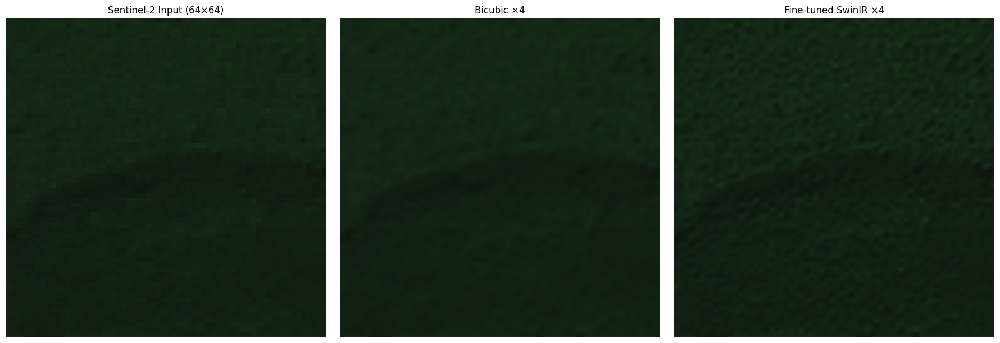

In [43]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(tensor_to_image(lr))
plt.title("Sentinel-2 Input (64×64)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(tensor_to_image(bicubic))
plt.title("Bicubic ×4")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(tensor_to_image(sr))
plt.title("Fine-tuned SwinIR ×4")
plt.axis("off")

plt.tight_layout()
plt.show()

In [44]:
def contrast_stretch(x, low=2, high=98):

    img = x.detach().cpu().numpy()

    lo = np.percentile(
        img,
        low,
        axis=(1, 2),
        keepdims=True
    )

    hi = np.percentile(
        img,
        high,
        axis=(1, 2),
        keepdims=True
    )

    stretched = (
        img - lo
    ) / (
        hi - lo + 1e-8
    )

    stretched = np.clip(
        stretched,
        0,
        1
    )

    return np.transpose(
        stretched,
        (1, 2, 0)
    )

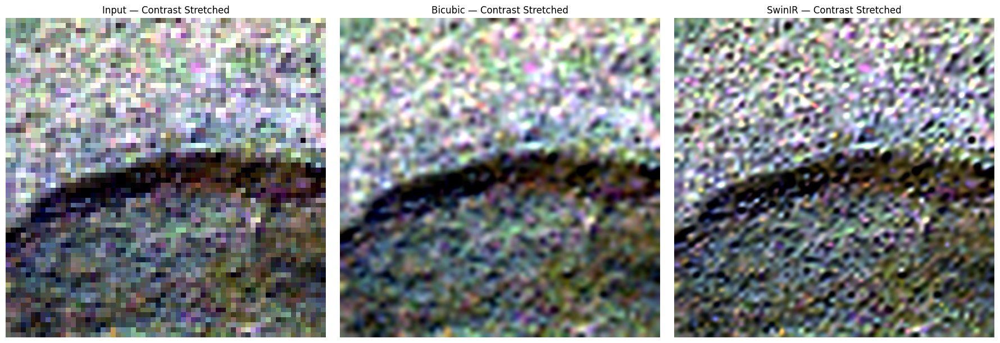

In [45]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(contrast_stretch(lr))
plt.title("Input — Contrast Stretched")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(contrast_stretch(bicubic))
plt.title("Bicubic — Contrast Stretched")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(contrast_stretch(sr))
plt.title("SwinIR — Contrast Stretched")
plt.axis("off")

plt.tight_layout()
plt.show()

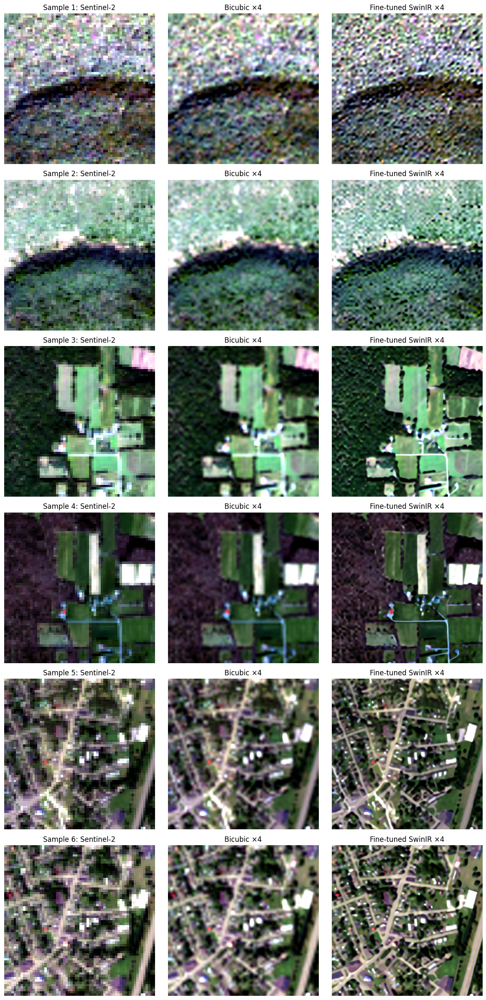

In [46]:
num_samples = 6

selected_files = files[:num_samples]

fig, axes = plt.subplots(
    num_samples,
    3,
    figsize=(12, 4 * num_samples)
)

for i, filename in enumerate(selected_files):

    path = os.path.join(
        test_folder,
        filename
    )

    lr = load_test_image(path)

    x = lr.unsqueeze(0).to(device)

    with torch.no_grad():
        sr = model(x)

    sr = sr.squeeze(0).cpu()

    bicubic = F.interpolate(
        lr.unsqueeze(0),
        scale_factor=4,
        mode="bicubic",
        align_corners=False
    ).squeeze(0)

    axes[i, 0].imshow(
        contrast_stretch(lr)
    )
    axes[i, 0].set_title(
        f"Sample {i+1}: Sentinel-2"
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(
        contrast_stretch(bicubic)
    )
    axes[i, 1].set_title(
        "Bicubic ×4"
    )
    axes[i, 1].axis("off")

    axes[i, 2].imshow(
        contrast_stretch(sr)
    )
    axes[i, 2].set_title(
        "Fine-tuned SwinIR ×4"
    )
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [52]:
from PIL import Image

img = Image.open(r"C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\vimanagar.jpg")  # change filename
print("Image size:", img.size)
print("Mode:", img.mode)

Image size: (64, 64)
Mode: RGB


In [54]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# Load external Sentinel-2 RGB image
img = Image.open(
    r"C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\vimanagar.jpg"
).convert("RGB")

# Convert to numpy
img_np = np.array(img)

print("Original shape:", img_np.shape)
print("Original min:", img_np.min())
print("Original max:", img_np.max())
print("Original mean:", img_np.mean())

Original shape: (64, 64, 3)
Original min: 0
Original max: 222
Original mean: 120.54256184895833


In [55]:
# Convert uint8 image [0,255] → float [0,1]
img_float = img_np.astype(np.float32) / 255.0

# HWC → CHW
x = torch.from_numpy(img_float).permute(2, 0, 1)

print("Tensor shape:", x.shape)
print("Tensor min:", x.min().item())
print("Tensor max:", x.max().item())
print("Tensor mean:", x.mean().item())

# Add batch dimension and move to GPU
x = x.unsqueeze(0).to(device)

# Inference
model.eval()

with torch.no_grad():
    sr = model(x)

# Remove batch dimension
sr = sr.squeeze(0).cpu()

print("\nOUTPUT")
print("Shape:", sr.shape)
print("Min:", sr.min().item())
print("Max:", sr.max().item())
print("Mean:", sr.mean().item())

Tensor shape: torch.Size([3, 64, 64])
Tensor min: 0.0
Tensor max: 0.8705882430076599
Tensor mean: 0.47271594405174255

OUTPUT
Shape: torch.Size([3, 256, 256])
Min: -0.039610475301742554
Max: 0.9209226369857788
Mean: 0.4723615348339081


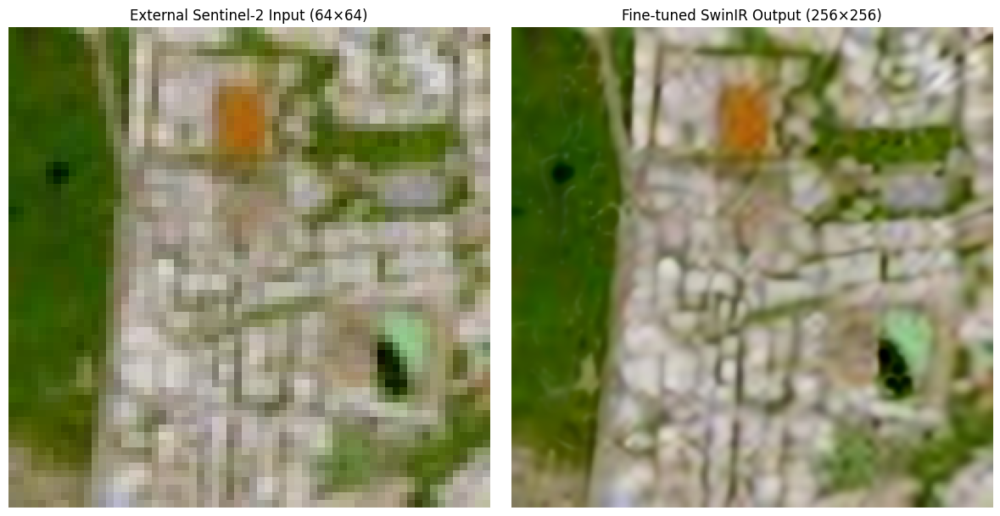

In [56]:
# Input tensor for display
input_img = x.squeeze(0).cpu().permute(1, 2, 0).numpy()

# SwinIR output for display
sr_img = sr.permute(1, 2, 0).numpy()

# Clip values for visualization
input_img = np.clip(input_img, 0, 1)
sr_img = np.clip(sr_img, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(input_img)
axes[0].set_title("External Sentinel-2 Input (64×64)")
axes[0].axis("off")

axes[1].imshow(sr_img)
axes[1].set_title("Fine-tuned SwinIR Output (256×256)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

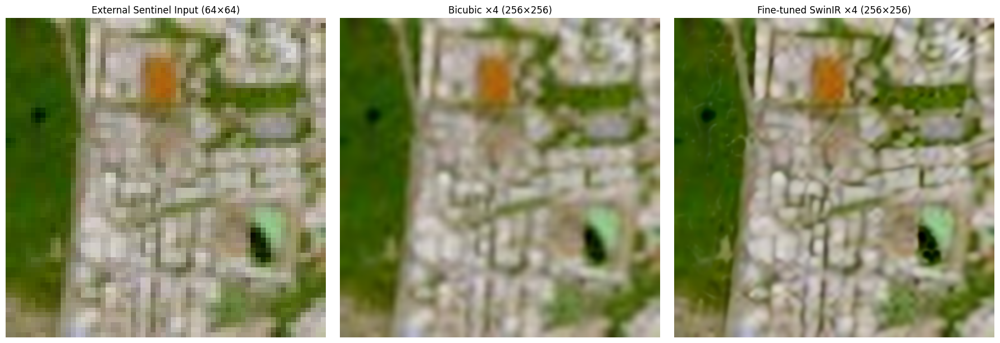

In [57]:
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Bicubic ×4
bicubic = F.interpolate(
    x,
    scale_factor=4,
    mode="bicubic",
    align_corners=False
)

bicubic_img = bicubic.squeeze(0).cpu().permute(1, 2, 0).numpy()

# SwinIR output
swinir_img = sr.permute(1, 2, 0).numpy()

# Input
input_img = x.squeeze(0).cpu().permute(1, 2, 0).numpy()

# Clip everything for display
input_img = np.clip(input_img, 0, 1)
bicubic_img = np.clip(bicubic_img, 0, 1)
swinir_img = np.clip(swinir_img, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(input_img)
axes[0].set_title("External Sentinel Input (64×64)")
axes[0].axis("off")

axes[1].imshow(bicubic_img)
axes[1].set_title("Bicubic ×4 (256×256)")
axes[1].axis("off")

axes[2].imshow(swinir_img)
axes[2].set_title("Fine-tuned SwinIR ×4 (256×256)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [63]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================
# UNCERTAINTY MAP FOR vimanagar.jpg
# ============================================

image_path = r"C:\Users\Anuj Pethe\OneDrive\Desktop\SIH ML PART\vimanagar.jpg"

# Load the exact image
img = Image.open(image_path).convert("RGB")
img_np = np.array(img).astype(np.float32) / 255.0

# HWC -> CHW -> batch
x = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    # Original prediction
    y_orig = model(x)

    # Horizontal flip
    y_hf = model(torch.flip(x, [2]))
    y_hf = torch.flip(y_hf, [2])

    # Vertical flip
    y_vf = model(torch.flip(x, [1]))
    y_vf = torch.flip(y_vf, [1])

    # EXACT uncertainty formula used in our project
    uncert = (
        torch.abs(y_orig - y_hf) +
        torch.abs(y_orig - y_vf)
    ) / 2.0

# Remove batch dimension
uncert = uncert.squeeze(0).cpu()

# Convert RGB uncertainty → single uncertainty map
uncertainty_map = uncert.mean(dim=0).numpy()

# Normalize exactly like our project
mx = uncertainty_map.max()

if mx > 0:
    uncertainty_map = uncertainty_map / mx

print("==========================================")
print("UNCERTAINTY MAP — vimanagar.jpg")
print("==========================================")
print("Input shape :", tuple(x.shape))
print("Map shape   :", uncertainty_map.shape)
print("Min         :", uncertainty_map.min())
print("Max         :", uncertainty_map.max())
print("Mean        :", uncertainty_map.mean())

UNCERTAINTY MAP — vimanagar.jpg
Input shape : (1, 3, 64, 64)
Map shape   : (256, 256)
Min         : 0.0037071756
Max         : 1.0
Mean        : 0.07157347


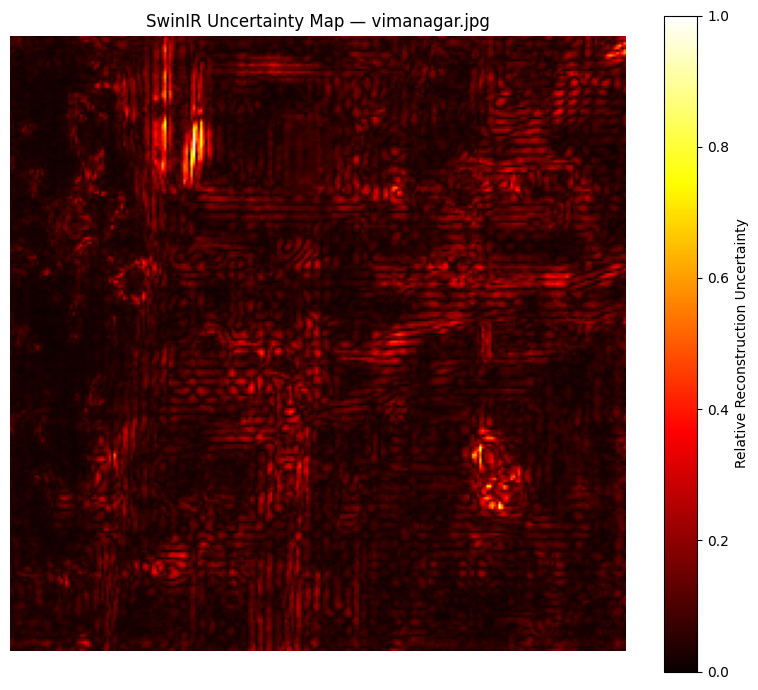

In [64]:
plt.figure(figsize=(8, 7))

im = plt.imshow(
    uncertainty_map,
    cmap="hot",
    vmin=0,
    vmax=1
)

plt.colorbar(
    im,
    label="Relative Reconstruction Uncertainty"
)

plt.title(
    "SwinIR Uncertainty Map — vimanagar.jpg"
)

plt.axis("off")
plt.tight_layout()
plt.show()

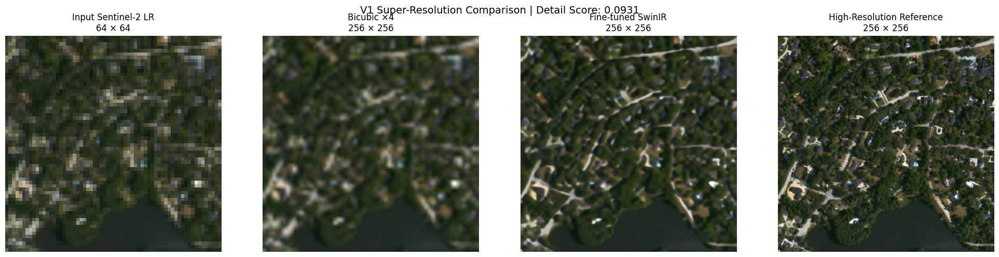

In [74]:
# ============================================================
# V1 Visual Comparison - Automatically Find Informative Sample
# ============================================================

import matplotlib.pyplot as plt
import torch.nn.functional as F

model.eval()

# Find the test image with the most spatial detail
best_score = -1
best_lr = None
best_hr = None
best_swinir = None
best_bicubic = None

with torch.no_grad():

    for lr_batch, hr_batch in test_loader:

        lr_gpu = lr_batch.to(device)

        # SwinIR output
        swinir_batch = model(lr_gpu).cpu()

        # Bicubic output
        bicubic_batch = F.interpolate(
            lr_batch,
            size=hr_batch.shape[-2:],
            mode="bicubic",
            align_corners=False
        )

        # Calculate spatial variation on HR reference
        # Higher variation = more interesting/detail-rich image
        gray = hr_batch.mean(dim=1)

        dx = torch.abs(gray[:, :, 1:] - gray[:, :, :-1]).mean(dim=(1, 2))
        dy = torch.abs(gray[:, 1:, :] - gray[:, :-1, :]).mean(dim=(1, 2))

        detail_score = dx + dy

        # Find best image in this batch
        batch_best = torch.argmax(detail_score).item()
        batch_score = detail_score[batch_best].item()

        if batch_score > best_score:
            best_score = batch_score

            best_lr = lr_batch[batch_best].clone()
            best_hr = hr_batch[batch_best].clone()
            best_swinir = swinir_batch[batch_best].clone()
            best_bicubic = bicubic_batch[batch_best].clone()


# Clamp values
best_lr = torch.clamp(best_lr, 0, 1)
best_bicubic = torch.clamp(best_bicubic, 0, 1)
best_swinir = torch.clamp(best_swinir, 0, 1)
best_hr = torch.clamp(best_hr, 0, 1)

# Convert CHW -> HWC
lr_img = best_lr.permute(1, 2, 0).numpy()
bicubic_img = best_bicubic.permute(1, 2, 0).numpy()
swinir_img = best_swinir.permute(1, 2, 0).numpy()
hr_img = best_hr.permute(1, 2, 0).numpy()


# ============================================================
# Display
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(lr_img)
axes[0].set_title("Input Sentinel-2 LR\n64 × 64")
axes[0].axis("off")

axes[1].imshow(bicubic_img)
axes[1].set_title("Bicubic ×4\n256 × 256")
axes[1].axis("off")

axes[2].imshow(swinir_img)
axes[2].set_title("Fine-tuned SwinIR\n256 × 256")
axes[2].axis("off")

axes[3].imshow(hr_img)
axes[3].set_title("High-Resolution Reference\n256 × 256")
axes[3].axis("off")

plt.suptitle(
    f"V1 Super-Resolution Comparison | Detail Score: {best_score:.4f}",
    fontsize=14
)

plt.tight_layout()
plt.show()

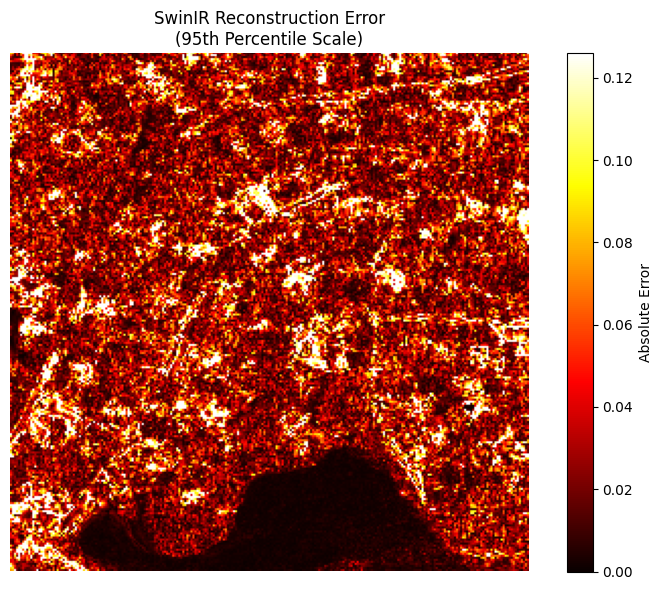

In [76]:
# ============================================================
# Improved SwinIR Error Map
# ============================================================

difference = torch.abs(best_swinir - best_hr)

# Average error across RGB channels
difference_map = difference.mean(dim=0).numpy()

# Use percentile-based scale for better visualization
vmax = np.percentile(difference_map, 95)

plt.figure(figsize=(8, 6))

plt.imshow(
    difference_map,
    cmap="hot",
    vmin=0,
    vmax=vmax
)

plt.colorbar(label="Absolute Error")

plt.title("SwinIR Reconstruction Error\n(95th Percentile Scale)")

plt.axis("off")
plt.tight_layout()
plt.show()